fraction evaporated into SM =  97.07100576179366  %
g_V =  7.486648777789885e-09
g_D =  7.486648777789888e-09
Oh2 = 700.8343583540436


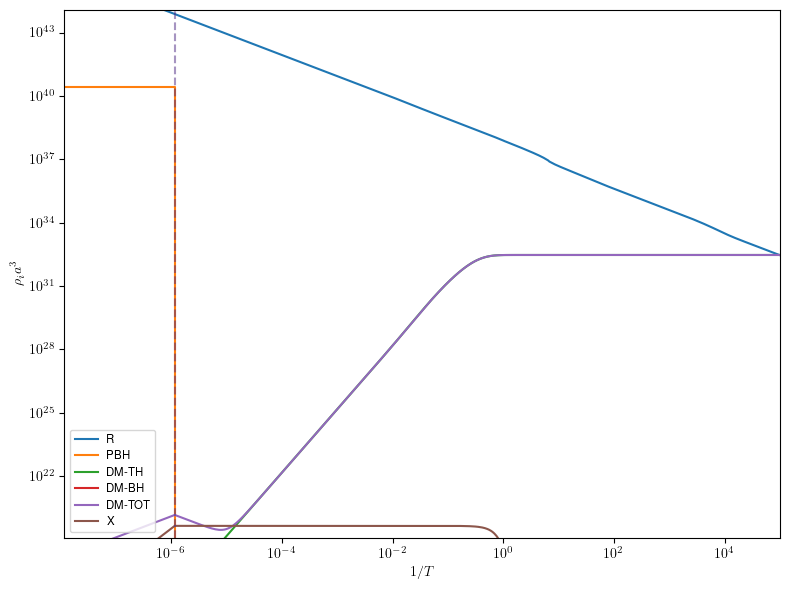

Is DM hot? --> False
relic numerics :  700.8343583540436
relic analytics :  1.5590296583993146
Thermalization of X -> False


In [1]:
###################################################################################################
#                                                                                                 #
#                        Primordial Black Hole Evaporation + DM Production                        #
#                                    Interplay with Freeze-In                                     #
#                                                                                                 #
#         Authors: Andrew Cheek, Lucien Heurtier, Yuber F. Perez-Gonzalez, Jessica Turner         #
#                                   Based on: arXiv:2107.xxxxx                                    #
#                                                                                                 #
###################################################################################################


import sys, os
path = os.path.abspath('')

import numpy as np
from scipy import interpolate, optimize
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy.integrate import quad, quad_vec, ode, solve_ivp, solve_bvp
from scipy.optimize import root, toms748
from scipy.special import zeta, kn, factorial, factorial2, eval_legendre, legendre, lpmn, lpmv, hyp2f1
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.optimize import minimize, rosen, rosen_der

from numpy import sqrt, log, exp, log10, pi, logspace, linspace, seterr, min, max, append
from numpy import loadtxt, zeros, floor, ceil, unique, sort, cbrt, concatenate, real, imag
from numpy import sin, cos, tan
from numpy import absolute, angle, array

from mpmath import polylog

from collections import OrderedDict
olderr = seterr(all='ignore')

sys.path.insert(1, path.replace("/dm",""))
from src import bhprop as bh #Schwarzschild and Kerr BHs library

# Import solving functions
from dm.freeze_in import FrInPBH as FrInFull # Freeze-In + PBH


#----- Package for LateX plotting -----
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,bm}')
#-----


# ----------- Input Parameters --------------
Mi    = 7.  # Log10@ Initial BH mass in g
ai    = 0.    # Initial a* value, a* = 0. -> Schwarzschild, a* > 0. -> Kerr.
bi    = -10.  # Log10@beta^\prime
mDM   = -3.   # Log10 @ DM Mass in GeV
mX    = 1.    # Log10 @ Mediaton Mass in GeV
mf    = -10.  # Log10 @ SM mass in GeV
sv    = -43.  # Log10 @ averaged cross section <sv>
BR    = 0.5   # Branching ratio to DM
g_DM  = 2     # DM degrees of freedom
model = 1     # Type of model --> fixed here to be one


Z=FrInFull(Mi, ai, bi, mDM, mX, mf, sv, BR, g_DM, model)

relic=Z.Omegah2()

relic_analytic=Z.Omegah2_analytics_FI()

print('relic numerics : ',relic)
print('relic analytics : ',relic_analytic[0])
if(relic_analytic[1]>=1):
    print('Thermalization of X -> True')
else:
    print('Thermalization of X -> False')